<a href="https://colab.research.google.com/github/christpaul94/MD1912/blob/main/MolecularDynamics/TrappedAtomsSimulation_RejectionSampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TrappedAtomsSimulation_RejectionSamplingTest

---



Author: Paul Christ

Date: 04.11.2025


In [10]:
!pip install -qq "git+https://github.com/christpaul94/MD1912.git#subdirectory=MolecularDynamics"

  Preparing metadata (setup.py) ... done


In [40]:
# Import
from TrappedAtomsSimulation.initialization import initialize_one_temp_gaussian_state, initialize_two_temp_gaussian_state
from TrappedAtomsSimulation.force_calculation import calculate_interaction_strength
from TrappedAtomsSimulation.plot_utils import plot_energy_and_error, plot_thermalization, plot_potential_and_distribution_by_axis
from TrappedAtomsSimulation.trap_potential_extended import calculate_single_beam_X_AXIS, calculate_single_beam_Y_AXIS, calculate_crossed_beam_dipole_potential, calculate_U0, calculate_crossed_trap_frequencies
from TrappedAtomsSimulation.initialization_rejection_sampling import prepare_one_temp_simulation_rejection, prepare_two_temp_simulation_rejection
# Import
from TrappedAtomsSimulation.initialization import initialize_one_temp_gaussian_state, initialize_two_temp_gaussian_state
from TrappedAtomsSimulation.force_calculation import calculate_interaction_strength
from TrappedAtomsSimulation.force_calculation import pair_keops_fp
from TrappedAtomsSimulation.integrators import run_verlet_simulation_HO, solve_harmonic_analytical, run_verlet_simulation_general, run_verlet_simulation_dynamic, run_harmonic_splitting_simulation, harmonic_fp
from TrappedAtomsSimulation.plot_utils import plot_energy_and_error, plot_thermalization
from TrappedAtomsSimulation.trap_potential_extended import calculate_single_beam_X_AXIS, calculate_single_beam_Y_AXIS, calculate_crossed_beam_dipole_potential, calculate_U0, calculate_crossed_trap_frequencies
#rom TrappedAtomsSimulation.verlet_list_force_calculation import run_verlet_list_simulation_general
from TrappedAtomsSimulation.initialization_rejection_sampling import prepare_one_temp_simulation_rejection, prepare_two_temp_simulation_rejection


import torch
import math
import time
import torch
import math
import time

In [12]:
### troch settings
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float32
kB = 1.380649e-23  # J/K
c_light = 299_792_458.0 # m/s
pi = math.pi

## Trap

In [14]:
trap_frequencies_Hz = (1000.0, 1050.0, 1200.0)
# Atommasse 87Rb
m_rb87 = 1.44160648e-25  # kg

# D1 Linie
omega_0_D1 = 2 * pi * 377.1074635e12 # rad/s
Gamma_D1 = 2 * pi * 5.746e6         # rad/s

# D2 Linie
omega_0_D2 = 2 * pi * 384.230484e12 # rad/s
Gamma_D2 = 2 * pi * 6.065e6         # rad/s

# Laserfrequenz
omega_L = 2 * pi * 280.179867e12    # rad/s


# Strahl 1 (X-Achse)
P_x = 5.18      # W
w0_x_SI = 41e-6   # m (41 µm)
zR_x_SI = 4.94e-3 # m (4.94 mm)

# Strahl 2 (Y-Achse)
P_y = 6.52      # W
w0_y_SI = 46e-6   # m (46 µm)
zR_y_SI = 6.21e-3 # m (6.21 mm)


# Gemeinsame Atom/Laser-Parameter
atom_laser_params = {
    "omega_L": omega_L,
    "omega_0_D1": omega_0_D1, "Gamma_D1": Gamma_D1,
    "omega_0_D2": omega_0_D2, "Gamma_D2": Gamma_D2
}


# Berechne U0 für Strahl 1
U0_1_SI = calculate_U0(P=P_x, w0=w0_x_SI, **atom_laser_params)

# Berechne U0 für Strahl 2
U0_2_SI = calculate_U0(P=P_y, w0=w0_y_SI, **atom_laser_params)

U0_1_in_uK = (U0_1_SI / kB) * 1e6
U0_2_in_uK = (U0_2_SI / kB) * 1e6

print("--- Berechnete Potentialtiefen (U0) ---")
print(f"  Strahl 1: {U0_1_in_uK:.1f} µK ")
print(f"  Strahl 2: {U0_2_in_uK:.1f} µK ")

trap_frequencies = calculate_crossed_trap_frequencies(
    U0_1=U0_1_SI, w0_1=w0_x_SI, zR_1=zR_x_SI,
    U0_2=U0_2_SI, w0_2=w0_y_SI, zR_2=zR_y_SI,
    m=m_rb87
)

print("\n--- Berechnete Frequenzen ---")
print(f"  f_x: {trap_frequencies['freq_x_hz']:.0f} Hz")
print(f"  f_y: {trap_frequencies['freq_y_hz']:.0f} Hz")
print(f"  f_z: {trap_frequencies['freq_z_hz']:.0f} Hz")
print(f"  f_mean: {trap_frequencies['freq_mean_hz']:.0f} Hz")


--- Berechnete Potentialtiefen (U0) ---
  Strahl 1: -294.8 µK 
  Strahl 2: -294.8 µK 

--- Berechnete Frequenzen ---
  f_x: 1163 Hz
  f_y: 1305 Hz
  f_z: 1747 Hz
  f_mean: 1384 Hz


### One group - Rejection Sampling

--- Skalierung basierend auf T = 1.00e-05 K ---
Längenskala L0: 4.23e-06 m, Energieskala E0: 1.38e-28 J, Zeitskala T0: 1.37e-04 s
Initialisiere 120000 Teilchen bei T = 1.00e-05 K
--- Initialisierung abgeschlossen ---

--- Skalierung basierend auf T_ref = 1.00e-05 K ---
Längenskala L0: 4.23e-06 m, Energieskala E0: 1.38e-28 J...
Verwende Bounding Box basierend auf T = 1.00e-05 K.
Initialisiere Gruppe (N=120000, T=1.00e-05 K)...
  -> Starte Rejection Sampling für 120000 Teilchen (T/T_ref = 1.00)...
  -> Sampling beendet. Akzeptanzrate: 0.06%
Dimensionslose Paar-Parameter: r=0.01237, c=1.623e-02
--- Ein-Temperatur-Initialisierung abgeschlossen ---



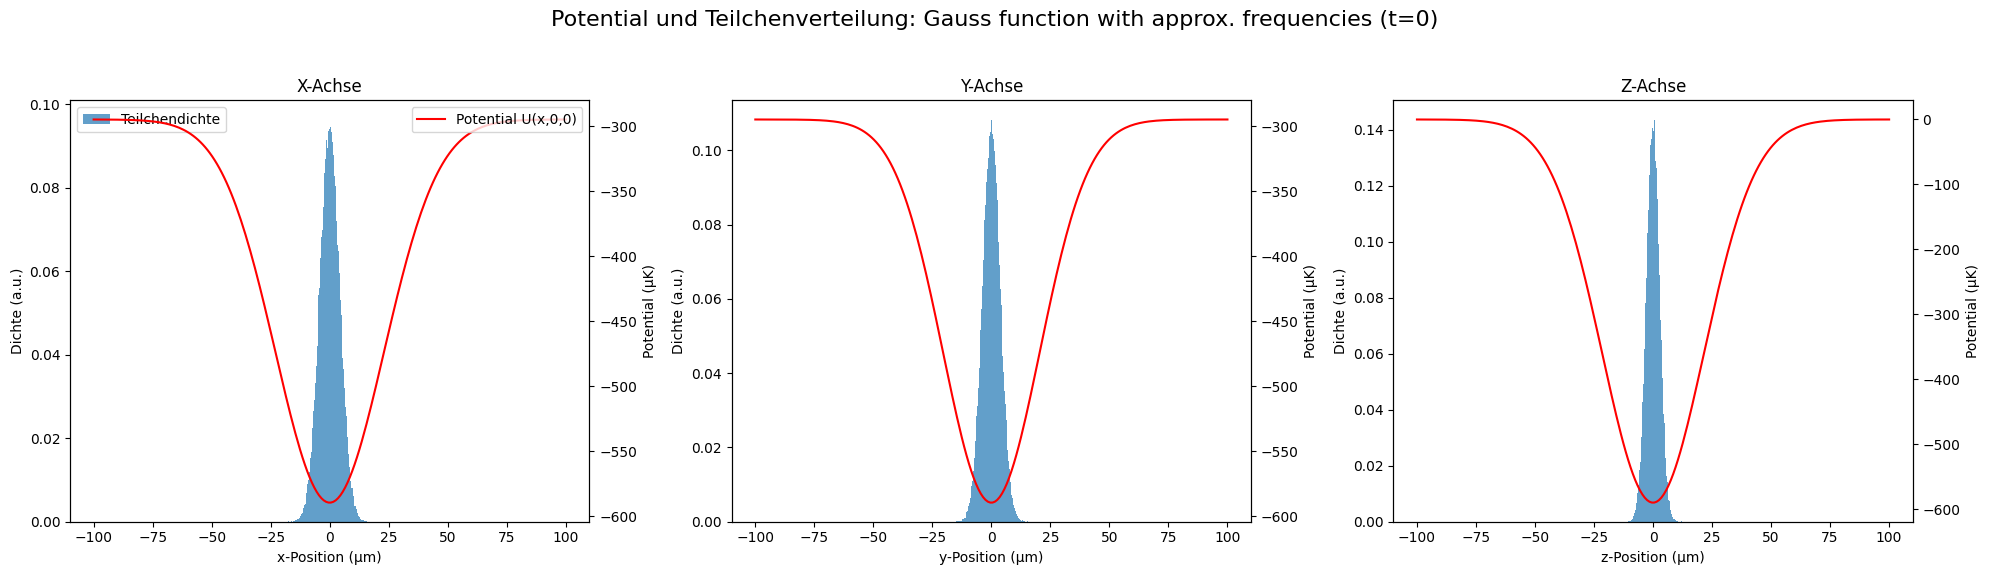

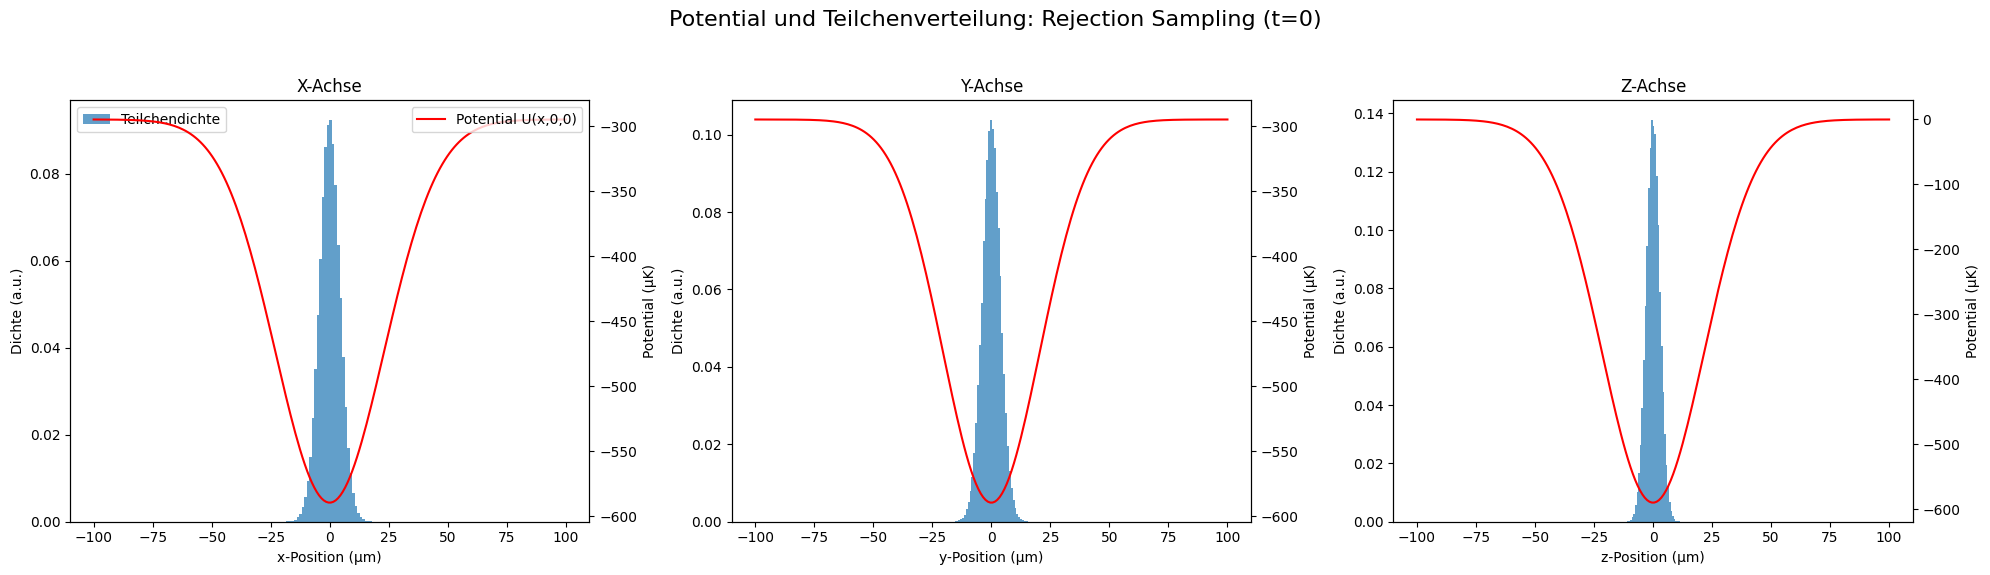

In [35]:
N_PARTICLES = 120000
TEMPERATURE_K = 10e-6
SIMULATION_TIME_S = 0.001      ### hier eigentlich unnötig, da nur Initialisierung getestet wird
TIMESTEP_S = 1e-5
SUBSTEPS = 5


# Wird für die Initialisierung der Gauß-verteilung un dsampliung bounding box benötigt
TRAP_FREQUENCIES_HZ = (trap_frequencies['freq_x_hz'],trap_frequencies['freq_y_hz'],trap_frequencies['freq_z_hz'])

# --- 3. Physikalische Wechselwirkungsparameter ---

r0_phys,C_phys = calculate_interaction_strength(10)

 # --- 4. Initialisierung ---

sim_init_params = initialize_one_temp_gaussian_state(
    n_particles=N_PARTICLES,
    temp_k=TEMPERATURE_K,
    omega_phys_hz=TRAP_FREQUENCIES_HZ,
    t_end_s=SIMULATION_TIME_S,
    dt_s=TIMESTEP_S,
    r0_phys=r0_phys,
    C_phys=C_phys,
    precision=torch.float32,
    device=device
)

# Skalierungsfaktoren
L0 = sim_init_params['L0_m']
E0 = sim_init_params['E0_J']
T0 = sim_init_params['T0_s']



# Parameter für die Dipolfalle
trap_params_extended = {
    "P_x": P_x, "P_y": P_y,
    "w0_x": w0_x_SI, "w0_y": w0_y_SI,
    "s0_x": zR_x_SI, "s0_y": zR_y_SI,
    "omega_L": omega_L,
    "omega_0_D1": omega_0_D1, "Gamma_D1": Gamma_D1,
    "omega_0_D2": omega_0_D2, "Gamma_D2": Gamma_D2,
    "L0": L0,
    "E0": E0
}

sim_init_params_rejection_sampling = prepare_one_temp_simulation_rejection(
    n_particles =N_PARTICLES,
    temp_k=TEMPERATURE_K,
    omega_phys_hz=TRAP_FREQUENCIES_HZ,
    t_end_s=SIMULATION_TIME_S,
    dt_s=TIMESTEP_S,
    r0_phys=r0_phys,
    C_phys=C_phys,
    trap_force_func=calculate_crossed_beam_dipole_potential,
    trap_params=trap_params_extended,
    precision=torch.float32,
    device=device
)



plot_potential_and_distribution_by_axis(
        positions=sim_init_params['q0'],
        trap_force_func=calculate_crossed_beam_dipole_potential,
        trap_params=trap_params_extended,
        title_suffix="Gauss function with approx. frequencies (t=0)",
        bins=100
    )
plot_potential_and_distribution_by_axis(
        positions=sim_init_params_rejection_sampling['q0'],
        trap_force_func=calculate_crossed_beam_dipole_potential,
        trap_params=trap_params_extended,
        title_suffix="Rejection Sampling (t=0)",
        bins=100
    )

--- Analyse: Gauss Approx (t=0) ---
   Zustandssumme Z (Theorie): 4.7213e-14


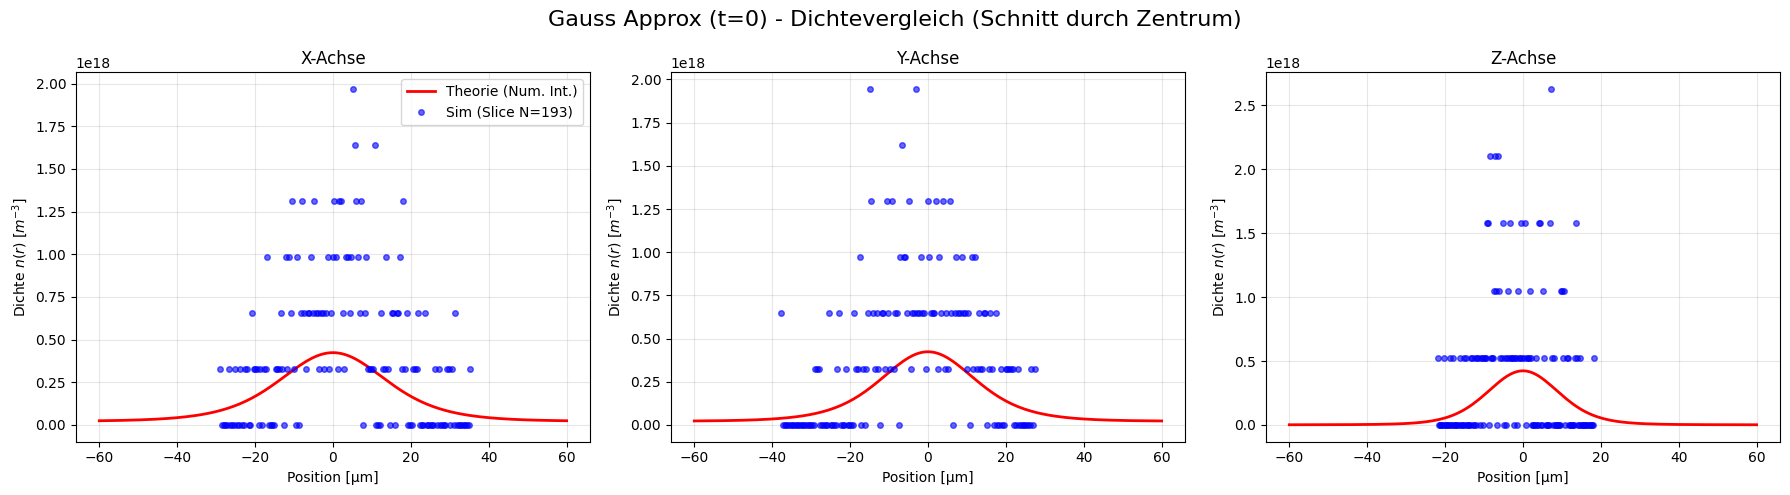

--- Analyse: Rejection Sampling (t=0) ---
   Zustandssumme Z (Theorie): 4.7213e-14


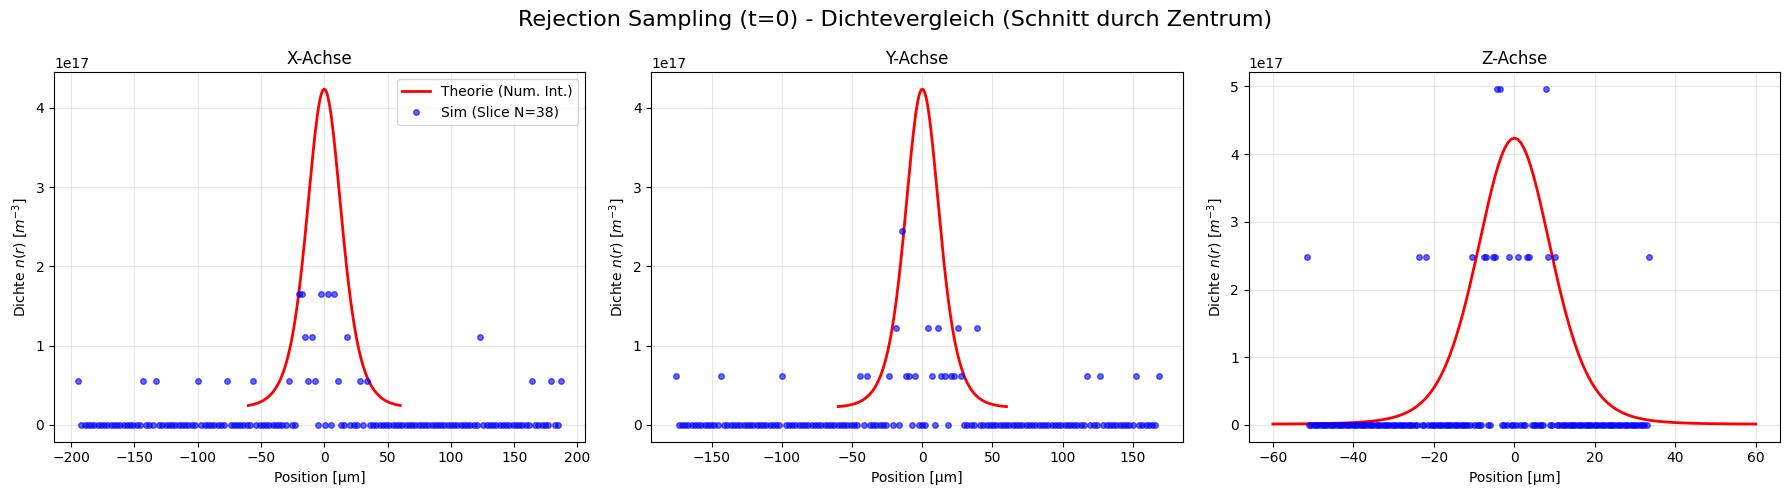

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import math

# ============================================================================
# 1. HILFSFUNKTION: Theoretische Dichte berechnen (KORRIGIERT)
# ============================================================================
def calculate_theory_density(trap_func, params, temp_k, n_particles, axis_idx=0):
    kB = 1.380649e-23

    # --- FIX: Tensor zu Float konvertieren ---
    L0 = params['L0']
    if isinstance(L0, torch.Tensor):
        L0 = L0.item()

    E0 = params['E0']
    if isinstance(E0, torch.Tensor):
        E0 = E0.item()
    # -----------------------------------------

    # A) Bestimme Zoom-Level
    test_pos = torch.zeros((1, 3), device=device) # device muss definiert sein (global)
    test_pos[:, axis_idx] = 1e-6 / L0

    # Hier params übergeben, aber L0/E0 im dict sind evtl noch Tensoren.
    # Das ist okay für die trap_func (die erwartet Tensoren),
    # aber für unsere Grid-Berechnung nutzen wir das lokale float L0.

    limit_um = 60.0
    limit_si = limit_um * 1e-6
    limit_dimless = limit_si / L0

    points = 151
    axis_vals = torch.linspace(-limit_dimless, limit_dimless, points, device=device)

    X, Y, Z = torch.meshgrid(axis_vals, axis_vals, axis_vals, indexing='ij')
    pos_grid = torch.stack([X.flatten(), Y.flatten(), Z.flatten()], dim=1)

    # B) Potential berechnen
    with torch.no_grad():
        _, _, V_dimless_flat = trap_func(pos_grid, **params)

    V_grid = V_dimless_flat.reshape(points, points, points)

    # C) Boltzmann
    V_min = torch.min(V_grid)
    V_diff = (V_grid - V_min) * E0 # Tensor * float ist okay in PyTorch

    boltzmann = torch.exp(-V_diff / (kB * temp_k))

    dx = (axis_vals[1] - axis_vals[0]).item()
    dV_si = (dx * L0)**3

    Z_numeric = torch.sum(boltzmann).item() * dV_si

    n_theory_grid = (n_particles / Z_numeric) * boltzmann

    mid = points // 2
    if axis_idx == 0:
        n_profile = n_theory_grid[:, mid, mid].cpu().numpy()
    elif axis_idx == 1:
        n_profile = n_theory_grid[mid, :, mid].cpu().numpy()
    else:
        n_profile = n_theory_grid[mid, mid, :].cpu().numpy()

    # HIER war der Fehler: L0 ist jetzt sicher ein float
    x_axis_um = axis_vals.cpu().numpy() * L0 * 1e6

    return x_axis_um, n_profile, Z_numeric


# ============================================================================
# 2. HILFSFUNKTION: Experimentelle Dichte (KORRIGIERT)
# ============================================================================
def get_sim_density(positions_dimless, L0_input, axis_idx=0, slice_width_um=5.0):

    # --- FIX: Sicherstellen, dass L0 ein float ist ---
    if isinstance(L0_input, torch.Tensor):
        L0 = L0_input.item()
    else:
        L0 = L0_input
    # -------------------------------------------------

    pos_um = positions_dimless.cpu().numpy() * L0 * 1e6

    slice_r = slice_width_um

    if axis_idx == 0:
        r_perp_sq = pos_um[:, 1]**2 + pos_um[:, 2]**2
        coords_on_axis = pos_um[:, 0]
    elif axis_idx == 1:
        r_perp_sq = pos_um[:, 0]**2 + pos_um[:, 2]**2
        coords_on_axis = pos_um[:, 1]
    else:
        r_perp_sq = pos_um[:, 0]**2 + pos_um[:, 1]**2
        coords_on_axis = pos_um[:, 2]

    mask = r_perp_sq < slice_width_um**2
    particles_in_slice = coords_on_axis[mask]

    bins = 150
    counts, bin_edges = np.histogram(particles_in_slice, bins=bins, density=False)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    bin_width_m = (bin_edges[1] - bin_edges[0]) * 1e-6
    slice_area_m2 = math.pi * (slice_width_um * 1e-6)**2
    volume_bin_m3 = bin_width_m * slice_area_m2

    # Schutz gegen Division durch Null, falls keine Teilchen da sind
    if volume_bin_m3 > 0:
        density_sim = counts / volume_bin_m3
    else:
        density_sim = np.zeros_like(counts)

    return bin_centers, density_sim, len(particles_in_slice)


# ============================================================================
# 3. PLOTTING & VERGLEICH
# ============================================================================

def compare_simulation_theory(positions, trap_func, params, T, N, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{title} - Dichtevergleich (Schnitt durch Zentrum)", fontsize=16)

    labels = ['X-Achse', 'Y-Achse', 'Z-Achse']

    print(f"--- Analyse: {title} ---")

    for i in range(3):
        ax = axes[i]

        # A) Theorie Kurve
        x_theo, n_theo, Z_val = calculate_theory_density(trap_func, params, T, N, axis_idx=i)

        # B) Simulation Daten (Slicing Methode)
        # Wähle Slice-Breite passend zur Temperatur (bei 1uK ca 2um okay)
        x_sim, n_sim, n_count = get_sim_density(positions, params['L0'], axis_idx=i, slice_width_um=1.5)

        # Plotten
        ax.plot(x_theo, n_theo, 'r-', linewidth=2, label='Theorie (Num. Int.)')
        # Fehlerbalken für Simulation (Poisson Rauschen)
        # n_err = n_sim / sqrt(counts) -> grob abschätzen
        ax.plot(x_sim, n_sim, 'bo', markersize=4, alpha=0.6, label=f'Sim (Slice N={n_count})')
        # Alternativ als Step-Plot:
        # ax.step(x_sim, n_sim, where='mid', color='blue', alpha=0.5)

        ax.set_title(labels[i])
        ax.set_xlabel("Position [µm]")
        ax.set_ylabel("Dichte $n(r)$ [$m^{-3}$]")
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend()
            print(f"   Zustandssumme Z (Theorie): {Z_val:.4e}")

    plt.tight_layout()
    plt.show()

# ============================================================================
# 4. AUSFÜHRUNG
# ============================================================================

# Vergleich 1: Gauss-Initialisierung (Approximation)
compare_simulation_theory(
    positions=sim_init_params['q0'],
    trap_func=calculate_crossed_beam_dipole_potential,
    params=trap_params_extended,
    T=TEMPERATURE_K,
    N=N_PARTICLES,
    title="Gauss Approx (t=0)"
)

# Vergleich 2: Rejection Sampling (Exakt)
compare_simulation_theory(
    positions=sim_init_params_rejection_sampling['q0'],
    trap_func=calculate_crossed_beam_dipole_potential,
    params=trap_params_extended,
    T=TEMPERATURE_K,
    N=N_PARTICLES,
    title="Rejection Sampling (t=0)"
)

--- Validierung: Simple & Correct ---
    Zoom-Bereich: +/- 15.6 µm
    Röhrchen-Radius: 1.17 µm


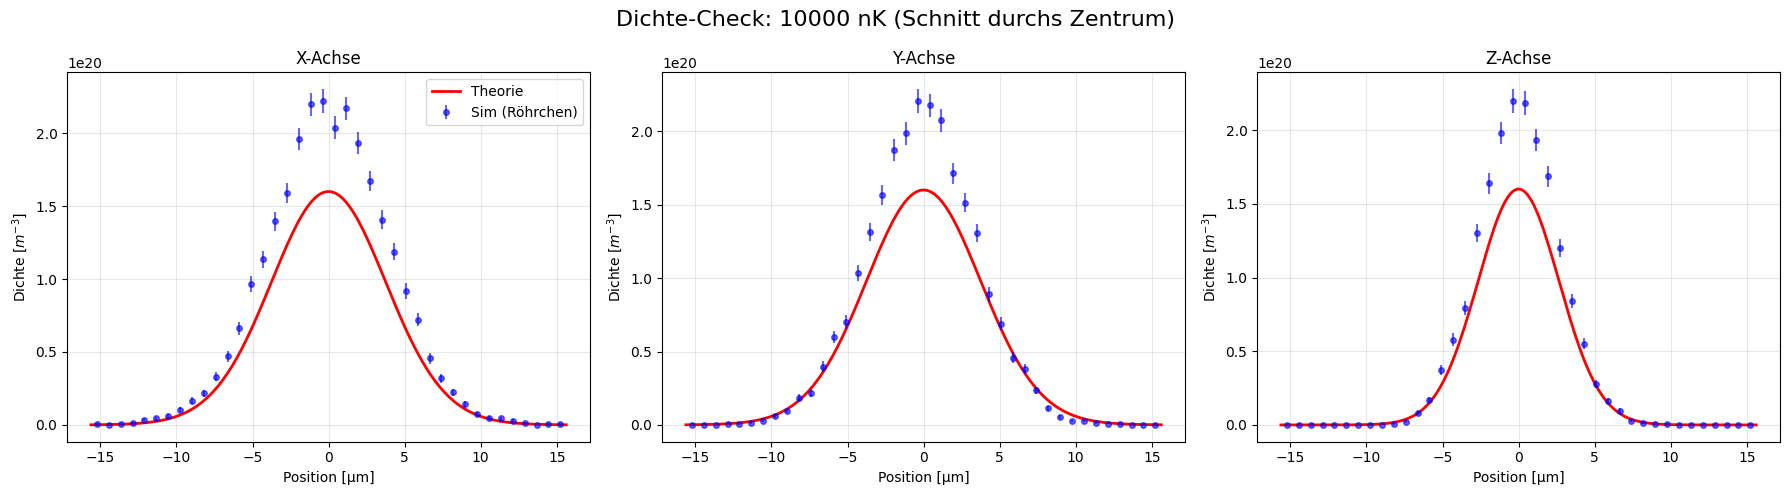

In [51]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import math

# ============================================================================
# SIMPLE & KORREKTE VALIDIERUNG (ZYLINDER-METHODE)
# ============================================================================

def validate_simple_and_correct(positions_tensor, trap_func, trap_params, temp_k, n_particles):

    # 1. Parameter vorbereiten (Tensor -> Zahl)
    L0 = trap_params['L0'].item() if isinstance(trap_params['L0'], torch.Tensor) else trap_params['L0']
    E0 = trap_params['E0'].item() if isinstance(trap_params['E0'], torch.Tensor) else trap_params['E0']
    kB = 1.380649e-23

    # Daten auf CPU und in Meter umrechnen
    pos_m = positions_tensor.detach().cpu().numpy() * L0

    # Bestimme Zoom automatisch (damit man bei 100 nK was sieht)
    sigma_guess = np.std(pos_m, axis=0).max()
    limit_m = max(4.0 * sigma_guess, 1.0e-6) # Zoom auf +/- 4 Sigma

    # Definiere das "Röhrchen" (Radius des Schnitts)
    # Ein guter Wert ist ca. 1/5 bis 1/3 der thermischen Breite sigma
    slice_radius_m = sigma_guess * 0.3

    print(f"--- Validierung: Simple & Correct ---")
    print(f"    Zoom-Bereich: +/- {limit_m*1e6:.1f} µm")
    print(f"    Röhrchen-Radius: {slice_radius_m*1e6:.2f} µm")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Dichte-Check: {temp_k*1e9:.0f} nK (Schnitt durchs Zentrum)', fontsize=16)
    labels = ['X-Achse', 'Y-Achse', 'Z-Achse']

    # --- ZUSTANDSSUMME Z FÜR THEORIE (Einmalig grob berechnen) ---
    # Nötig, damit die rote Kurve die richtige Höhe hat
    # Wir nutzen hierfür PyTorch auf dem Gitter
    grid_pts = 61
    ax_z = torch.linspace(-limit_m/L0, limit_m/L0, grid_pts, device=positions_tensor.device)
    X, Y, Z = torch.meshgrid(ax_z, ax_z, ax_z, indexing='ij')
    pos_grid = torch.stack([X.flatten(), Y.flatten(), Z.flatten()], dim=1)
    with torch.no_grad():
        _, _, V_grid = trap_func(pos_grid, **trap_params)
    V_min = V_grid.min()
    boltzmann = torch.exp(-(V_grid - V_min) * E0 / (kB * temp_k))
    Z_val = torch.sum(boltzmann).item() * ( (ax_z[1]-ax_z[0]).item() * L0 )**3


    # --- SCHLEIFE ÜBER X, Y, Z ---
    for i in range(3):
        ax = axes[i]

        # A) THEORIE (Rote Linie)
        # Wir berechnen n(r) auf der Achse
        # Vektor mit Punkten auf der Achse erstellen
        r_axis_dimless = torch.linspace(-limit_m/L0, limit_m/L0, 200, device=positions_tensor.device)
        zeros = torch.zeros_like(r_axis_dimless)

        if i == 0:   coords = torch.stack([r_axis_dimless, zeros, zeros], dim=1)
        elif i == 1: coords = torch.stack([zeros, r_axis_dimless, zeros], dim=1)
        else:        coords = torch.stack([zeros, zeros, r_axis_dimless], dim=1)

        with torch.no_grad():
            _, _, V_axis = trap_func(coords, **trap_params)

        # n = (N/Z) * exp(-V/kT)
        n_theo = (n_particles / Z_val) * torch.exp(-(V_axis - V_min) * E0 / (kB * temp_k)).cpu().numpy()
        x_theo_um = r_axis_dimless.cpu().numpy() * L0 * 1e6


        # B) SIMULATION (Blaue Balken / Punkte)
        # 1. Filter: Welche Teilchen sind im Röhrchen?
        # Radius r^2 = y^2 + z^2 (für X-Achse)
        other_axes = [dim for dim in [0,1,2] if dim != i]
        r_sq = pos_m[:, other_axes[0]]**2 + pos_m[:, other_axes[1]]**2

        # Maske: Nur Teilchen im Röhrchen
        in_tube = r_sq < slice_radius_m**2
        pos_on_axis = pos_m[in_tube, i] # Nur die relevante Koordinate

        # 2. Histogramm berechnen
        counts, bin_edges = np.histogram(pos_on_axis, bins=40, range=(-limit_m, limit_m))
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        # 3. KORREKTUR: Anzahl -> Dichte
        # Dichte = Anzahl / Volumen_des_Bin_Stücks
        # Volumen = (Bin_Breite) * (Kreisfläche des Röhrchens)
        bin_width = bin_edges[1] - bin_edges[0]
        tube_area = math.pi * slice_radius_m**2
        vol_bin = bin_width * tube_area

        n_sim = counts / vol_bin # Jetzt ist es in m^-3 !

        # C) PLOTTEN
        ax.plot(x_theo_um, n_theo, 'r-', linewidth=2, label='Theorie')
        # Wir plotten die Sim-Daten als Punkte mit Fehlerbalken (sieht professionell aus)
        ax.errorbar(bin_centers*1e6, n_sim, yerr=np.sqrt(counts)/vol_bin, fmt='bo', markersize=4, alpha=0.6, label='Sim (Röhrchen)')

        ax.set_title(labels[i])
        ax.set_xlabel("Position [µm]")
        ax.set_ylabel("Dichte [$m^{-3}$]")
        ax.grid(True, alpha=0.3)

        if i == 0: ax.legend()

    plt.tight_layout()
    plt.show()

# --- AUFRUF ---
validate_simple_and_correct(
    positions_tensor=sim_init_params_rejection_sampling['q0'],
    trap_func=calculate_crossed_beam_dipole_potential,
    trap_params=trap_params_extended,
    temp_k=TEMPERATURE_K,
    n_particles=N_PARTICLES
)

In [48]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
import math

# =============================================================================
# 1. PARAMETER & PHYSIK SETUP
# =============================================================================

# Naturkonstanten & Parameter
m_rb87 = 1.44160648e-25
kB = 1.380649e-23
pi = torch.pi
omega_L = 2 * pi * 280.179867e12
omega_0_D1 = 2 * pi * 377.1074635e12; Gamma_D1 = 2 * pi * 5.746e6
omega_0_D2 = 2 * pi * 384.230484e12; Gamma_D2 = 2 * pi * 6.065e6

# Laser Konfiguration (Starke Falle für 10 uK)
P_x, P_y = 5.18, 5.18
w0_x_SI, w0_y_SI = 41e-6, 41e-6
zR_x_SI, zR_y_SI = 4.94e-3, 4.94e-3

# Simulation Settings
N_PARTICLES = 100000
TEMPERATURE_K = 10e-6    # 10 uK
SIMULATION_TIME_S = 0.01 # 20 ms reichen zum Thermalisieren
TIMESTEP_S = 1e-5        # 10 µs Schrittweite
SUBSTEPS = 5             # 5 Substeps pro Schritt
THERMALIZATION_STEPS = 1000 # Anzahl Schritte für Burn-In

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. U0 und Frequenzen berechnen (für Skalierung)
atom_laser_params = {"omega_L": omega_L, "omega_0_D1": omega_0_D1, "Gamma_D1": Gamma_D1, "omega_0_D2": omega_0_D2, "Gamma_D2": Gamma_D2}
U0_1_SI = calculate_U0(P=P_x, w0=w0_x_SI, **atom_laser_params)
U0_2_SI = calculate_U0(P=P_y, w0=w0_y_SI, **atom_laser_params)

trap_frequencies = calculate_crossed_trap_frequencies(U0_1_SI, w0_x_SI, zR_x_SI, U0_2_SI, w0_y_SI, zR_y_SI, m_rb87)
TRAP_FREQUENCIES_HZ = (trap_frequencies['freq_x_hz'], trap_frequencies['freq_y_hz'], trap_frequencies['freq_z_hz'])

print(f"--- Setup ---")
print(f"Temperatur: {TEMPERATURE_K*1e6:.1f} µK")
print(f"Frequenzen: {trap_frequencies['freq_x_hz']:.0f}, {trap_frequencies['freq_y_hz']:.0f}, {trap_frequencies['freq_z_hz']:.0f} Hz")


# =============================================================================
# 2. INITIALISIERUNG (Gauß -> Einheiten -> Rejection)
# =============================================================================

# A) Dummy-Initialisierung (nur für Einheiten L0, E0, T0)
dummy_init = initialize_one_temp_gaussian_state(
    n_particles=10, temp_k=TEMPERATURE_K, omega_phys_hz=TRAP_FREQUENCIES_HZ,
    t_end_s=SIMULATION_TIME_S, dt_s=TIMESTEP_S, r0_phys=1e-9, C_phys=0.0,
    device=device
)

# --- FEHLERBEHEBUNG: .item() verwenden, um Tensor in float zu wandeln ---
L0_tensor = dummy_init['L0_m']
E0_tensor = dummy_init['E0_J']
T0_tensor = dummy_init['T0_s']

L0 = L0_tensor.item() if isinstance(L0_tensor, torch.Tensor) else L0_tensor
E0 = E0_tensor.item() if isinstance(E0_tensor, torch.Tensor) else E0_tensor
T0 = T0_tensor.item() if isinstance(T0_tensor, torch.Tensor) else T0_tensor
# ------------------------------------------------------------------------

# Parameter-Dict für Potential-Funktion
trap_params_extended = {
    "P_x": P_x, "P_y": P_y, "w0_x": w0_x_SI, "w0_y": w0_y_SI, "s0_x": zR_x_SI, "s0_y": zR_y_SI,
    **atom_laser_params, "L0": L0, "E0": E0
}

# B) Echtes Rejection Sampling (mit korrekter Potentialform)
# Wechselwirkung C_phys berechnen
r0_phys, C_phys = calculate_interaction_strength(100) # C_phys in SI

print("\n--- Starte Rejection Sampling ---")
sim_init = prepare_one_temp_simulation_rejection(
    n_particles=N_PARTICLES,
    temp_k=TEMPERATURE_K,
    omega_phys_hz=TRAP_FREQUENCIES_HZ,
    t_end_s=SIMULATION_TIME_S,
    dt_s=TIMESTEP_S,
    r0_phys=r0_phys,
    C_phys=C_phys, # Hier echte WW nutzen!
    trap_force_func=calculate_crossed_beam_dipole_potential,
    trap_params=trap_params_extended,
    precision=torch.float32,
    device=device
)
print("Rejection Sampling fertig.")


# =============================================================================
# 3. THERMALISIERUNG (Simulation mit Thermostat)
# =============================================================================

target_temp_dimless = 1.0
tau_dimless = 10.0 * sim_init['t_values'][1] # 10 Zeitschritte als Tau

print(f"\n>>> Starte Haupt-Thermalisierung (Berendsen)")
print(f"    Ziel: {target_temp_dimless:.2f} (dimless) | Steps: {THERMALIZATION_STEPS}")

results = run_verlet_simulation_general_thermostat(
    t_values=sim_init['t_values'],
    q0=sim_init['q0'], # Wir starten wieder beim frischen Initial-Zustand!
    p0=sim_init['p0'],
    trap_force_func=calculate_crossed_beam_dipole_potential,
    trap_force_params=trap_params_extended,
    pair_force_func=pair_keops_fp,
    pair_force_params=sim_init['pair_force_params'],
    precision_type=torch.float32,
    device=device,
    substeps=SUBSTEPS,
    # THERMOSTAT PARAMETER:
    target_temperature=target_temp_dimless,
    thermostat_tau=tau_dimless,
    burn_in_steps=THERMALIZATION_STEPS * SUBSTEPS
)

# =============================================================================
# 4. VALIDIERUNG & PLOTTING (Nach Thermalisierung)
# =============================================================================

# Wir nehmen den allerletzten Zeitschritt der Simulation
final_positions = results['positions'][-1]
final_kinetic = results['kinetic_energy'][-1]

# Temperatur-Check am Ende
T_final_dimless = (2.0 * final_kinetic) / (3.0 * N_PARTICLES)
T_final_K = T_final_dimless.item() * E0 / kB

print(f"\n--- Ergebnis nach Thermalisierung ---")
print(f"End-Temperatur: {T_final_K*1e6:.2f} µK (Soll: {TEMPERATURE_K*1e6:.1f} µK)")

# Plotten mit der validierten "Simple & Correct" Methode
validate_simple_and_correct(
    positions_tensor=final_positions,
    trap_func=calculate_crossed_beam_dipole_potential,
    trap_params=trap_params_extended,
    temp_k=TEMPERATURE_K, # Wir vergleichen gegen die Zieltemperatur
    n_particles=N_PARTICLES
)

--- Setup ---
Temperatur: 10.0 µK
Frequenzen: 1305, 1305, 1845 Hz
--- Skalierung basierend auf T = 1.00e-05 K ---
Längenskala L0: 3.77e-06 m, Energieskala E0: 1.38e-28 J, Zeitskala T0: 1.22e-04 s
Initialisiere 10 Teilchen bei T = 1.00e-05 K
--- Initialisierung abgeschlossen ---


--- Starte Rejection Sampling ---
--- Skalierung basierend auf T_ref = 1.00e-05 K ---
Längenskala L0: 3.77e-06 m, Energieskala E0: 1.38e-28 J...
Verwende Bounding Box basierend auf T = 1.00e-05 K.
Initialisiere Gruppe (N=100000, T=1.00e-05 K)...
  -> Starte Rejection Sampling für 100000 Teilchen (T/T_ref = 1.00)...
  -> Sampling beendet. Akzeptanzrate: 0.06%
Dimensionslose Paar-Parameter: r=0.13880, c=1.623e-05
--- Ein-Temperatur-Initialisierung abgeschlossen ---

Rejection Sampling fertig.

>>> Starte Haupt-Thermalisierung (Berendsen)
    Ziel: 1.00 (dimless) | Steps: 1000
[COOLING] Integration 15% | ETA: 7 min 47 s

KeyboardInterrupt: 

In [38]:
import torch
import time
from typing import Callable, Dict

def run_verlet_simulation_general_thermostat(
    t_values: torch.Tensor,
    q0: torch.Tensor,
    p0: torch.Tensor,
    trap_force_func: Callable,
    trap_force_params: Dict,
    pair_force_func: Callable,
    pair_force_params: Dict,
    precision_type: torch.dtype = torch.float32,
    device: torch.device = torch.device('cuda'),
    substeps: int = 100,
    silent: bool = False,
    # --- NEU: Thermostat Parameter ---
    target_temperature: float = 1.0,  # Zieltemperatur (None = Thermostat AUS)
    thermostat_tau: float =0.4,      # Relaxationszeit (z.B. 10*dt)
    burn_in_steps: int = 2000,            # Anzahl Schritte (substeps), in denen gekühlt wird
    **kwargs
) -> Dict[str, torch.Tensor]:

    with torch.no_grad():
        num_save_points, n_particles = t_values.size(0), q0.size(0)

        q_out = torch.empty((num_save_points, n_particles, 3), dtype=precision_type, device=device)
        p_out = torch.empty((num_save_points, n_particles, 3), dtype=precision_type, device=device)
        kinetic_energy_out = torch.empty(num_save_points, dtype=precision_type, device=device)
        potential_trap_out = torch.empty(num_save_points, dtype=precision_type, device=device)
        potential_pair_out = torch.empty(num_save_points, dtype=precision_type, device=device)

        q_curr = q0.to(device, precision_type)
        p_curr = p0.to(device, precision_type)

        # --- Initialisierung (t=0) ---
        f_trap, pot_trap, _ = trap_force_func(q_curr, **trap_force_params)
        f_pair, pot_pair = pair_force_func(q_curr, **pair_force_params)
        a_curr = f_trap + f_pair

        q_out[0], p_out[0] = q_curr, p_curr
        kinetic_energy_out[0] = 0.5 * torch.sum(p_curr**2)
        potential_trap_out[0], potential_pair_out[0] = pot_trap, pot_pair

        # Zähler für Gesamt-Schritte (für Burn-in Logik)
        total_step_counter = 0

        # --- HILFSFUNKTION: Berendsen Thermostat ---
        def apply_berendsen(p, dt_step):
            # Prüfen ob Thermostat aktiv ist (burn-in Phase oder generell an)
            is_active = (target_temperature is not None) and \
                        (thermostat_tau is not None) and \
                        (total_step_counter < burn_in_steps)

            if not is_active:
                return p

            # 1. Aktuelle Temperatur berechnen (T ~ 2/3N * E_kin)
            # Hinweis: Wir nehmen an, dass target_temperature in denselben
            # "Energie-Einheiten" ist wie p^2.
            E_kin_curr = 0.5 * torch.sum(p**2)
            # Um numerische Instabilität bei Start-Energie ~ 0 zu vermeiden:
            if E_kin_curr < 1e-12: return p

            T_curr = (2.0 * E_kin_curr) / (3.0 * n_particles)

            # 2. Skalierungsfaktor lambda berechnen
            # lambda = sqrt(1 + dt/tau * (T_target / T_curr - 1))
            lam = torch.sqrt(1.0 + (dt_step / thermostat_tau) * (target_temperature / T_curr - 1.0))

            # Begrenzung des Faktors für extreme Starts (Sicherheitsnetz)
            lam = torch.clamp(lam, 0.5, 1.5)

            return p * lam


        # --- Äußere Zeitschleife ---
        for i in range(1, num_save_points):
            loop_start_time = time.perf_counter()
            Dt = t_values[i] - t_values[i - 1]
            dt = Dt / substeps

            # === PHASE 1: Start (Erster Halber Kick) ===
            p_curr = p_curr + 0.5 * dt * a_curr

            # (Optional: Auch hier kann man kühlen, wir machen es aber meist nach vollen Kicks)

            # === PHASE 2: Mittelteil (Leapfrog Loop) ===
            for _ in range(substeps - 1):
                total_step_counter += 1 # Schritt zählen

                # 1. Ganzer Drift
                q_curr = q_curr + dt * p_curr

                # 2. Kräfte Update
                f_trap, _, _ = trap_force_func(q_curr, **trap_force_params)
                f_pair, _ = pair_force_func(q_curr, **pair_force_params)
                a_curr = f_trap + f_pair

                # 3. Ganzer Kick
                p_curr = p_curr + dt * a_curr

                # --- THERMOSTAT ANWENDEN ---
                # Wir skalieren den Impuls direkt hier in der Schleife
                p_curr = apply_berendsen(p_curr, dt)

            # === PHASE 3: Ende (Letzter Schritt & Sync) ===
            total_step_counter += 1

            # 1. Letzter Drift
            q_curr = q_curr + dt * p_curr

            # 2. Letzte Kraftberechnung
            f_trap, pot_trap, _ = trap_force_func(q_curr, **trap_force_params)
            f_pair, pot_pair = pair_force_func(q_curr, **pair_force_params)
            a_curr = f_trap + f_pair

            # 3. Letzter Halber Kick (Synchronisierung)
            p_curr = p_curr + 0.5 * dt * a_curr

            # --- THERMOSTAT ANWENDEN (Synchronisation) ---
            # Wichtig: Nochmal skalieren, damit die gespeicherte Energie sauber ist
            p_curr = apply_berendsen(p_curr, dt)


            # === Speichern ===
            q_out[i], p_out[i] = q_curr, p_curr
            kinetic_energy_out[i] = 0.5 * torch.sum(p_curr**2)
            potential_trap_out[i] = pot_trap
            potential_pair_out[i] = pot_pair

            # Logging
            if not silent:
                loop_end_time = time.perf_counter()
                eta_seconds = int((loop_end_time - loop_start_time) * (num_save_points - 1 - i))

                # Info ob Thermostat an ist in den Print einbauen
                thermo_state = "[COOLING]" if total_step_counter < burn_in_steps else "[NVE]"

                print(f"\r{thermo_state} Integration {100 * (i + 1) / num_save_points:.0f}% "
                      f"| ETA: {eta_seconds // 60} min {eta_seconds % 60} s", end='', flush=True)

    print("\nIntegration abgeschlossen.")
    return {
        "times": t_values, "positions": q_out, "momenta": p_out,
        "kinetic_energy": kinetic_energy_out,
        "potential_energy_trap": potential_trap_out,
        "potential_energy_pair": potential_pair_out
    }
